In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd
import numpy as np


In [9]:
df = pd.read_csv('olist_customers_dataset.csv')

In [10]:
df.head
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


In [11]:
customers_by_state  = df['customer_state'].value_counts()
customers_by_state

,count
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


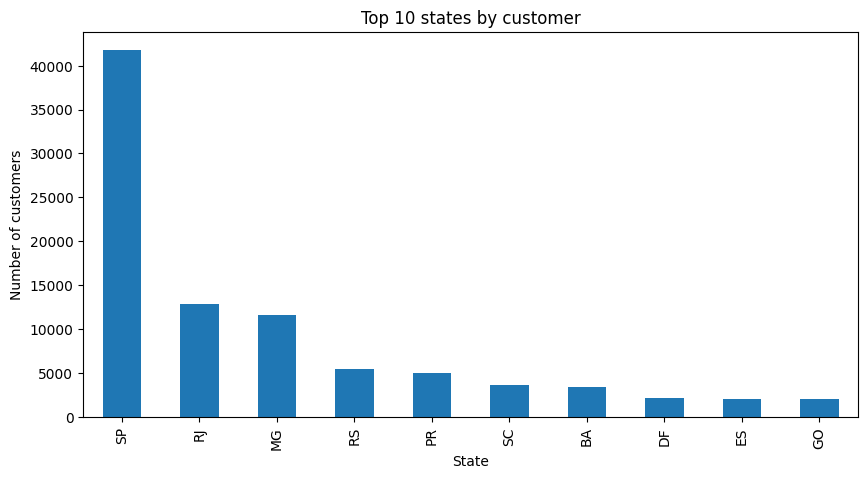

In [12]:
import matplotlib.pyplot as plt

customers_by_state.head(10).plot(
    kind = 'bar',
    figsize=(10,5)
)

plt.title('Top 10 states by customer')
plt.xlabel('State')
plt.ylabel('Number of customers')
plt.show()

In [13]:
customers_by_city = df['customer_city'].value_counts().head(10)
customers_by_city

,count
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


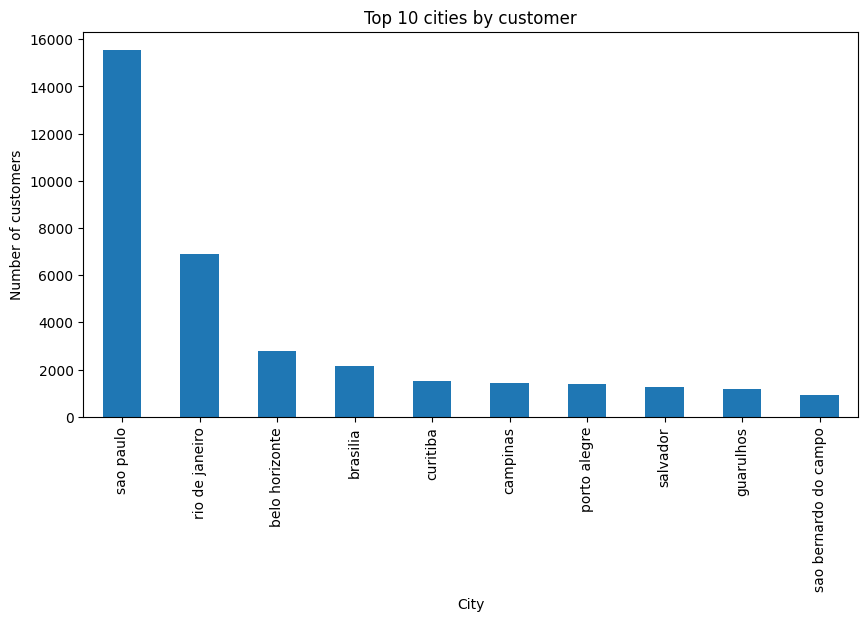

In [14]:
customers_by_city.plot(
    kind = 'bar',
    figsize=(10,5)
)

plt.title('Top 10 cities by customer')
plt.xlabel('City')
plt.ylabel('Number of customers')
plt.show()


In [15]:
import pandas as pd

orders = pd.read_csv('olist_orders_dataset.csv')
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [16]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [17]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [18]:
orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [19]:
orders_clean = orders.copy()

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders_clean[col] = pd.to_datetime(orders_clean[col])

In [20]:
delivered_orders = orders_clean[orders_clean['order_status'] == 'delivered']
delivered_orders.shape

(96478, 8)

In [21]:
delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date']
    - delivered_orders['order_purchase_timestamp']
    ).dt.days

delivered_orders['delivery_days'].mean()

orders['order_status'].value_counts()

/tmp/ipykernel_2240/3318000835.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered_orders['delivery_days'] = (


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [22]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders['month'] = orders['order_purchase_timestamp'].dt.month_name()

monthly_orders = orders.groupby('month').size()
monthly_orders

,0
month,
April,9343
August,10843
December,5674
February,8508
January,8069
July,10318
June,9412
March,9893
May,10573


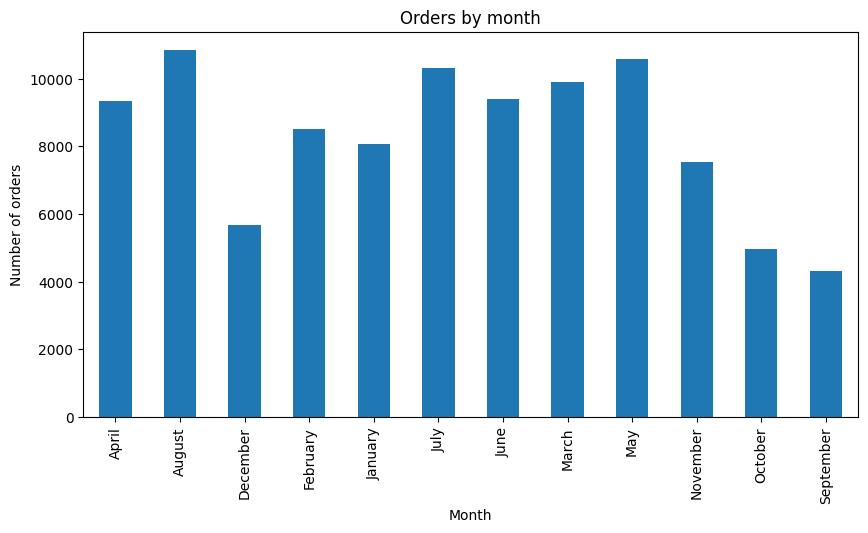

In [23]:
import matplotlib.pyplot as plt

monthly_orders.plot(
    kind = 'bar',
    figsize = (10,5)
)
plt.title('Orders by month')
plt.xlabel('Month')
plt.ylabel('Number of orders')
plt.show()


In [24]:
import pandas as pd

items = pd.read_csv("olist_order_items_dataset.csv")
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [25]:
items.info()
items.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [26]:
items['price'].sum()


np.float64(13591643.700000003)

In [27]:
items['price'].mean()

np.float64(120.65373901464716)

In [28]:
top_orders = items.groupby('order_id')['price'].sum().sort_values(ascending=False)

top_orders.head(10)

,price
order_id,
03caa2c082116e1d31e67e9ae3700499,13440.0
736e1922ae60d0d6a89247b851902527,7160.0
0812eb902a67711a1cb742b3cdaa65ae,6735.0
fefacc66af859508bf1a7934eab1e97f,6729.0
f5136e38d1a14a4dbd87dff67da82701,6499.0
2cc9089445046817a7539d90805e6e5a,5934.6
a96610ab360d42a2e5335a3998b4718a,4799.0
199af31afc78c699f0dbf71fb178d4d4,4690.0
b4c4b76c642808cbe472a32b86cddc95,4599.9


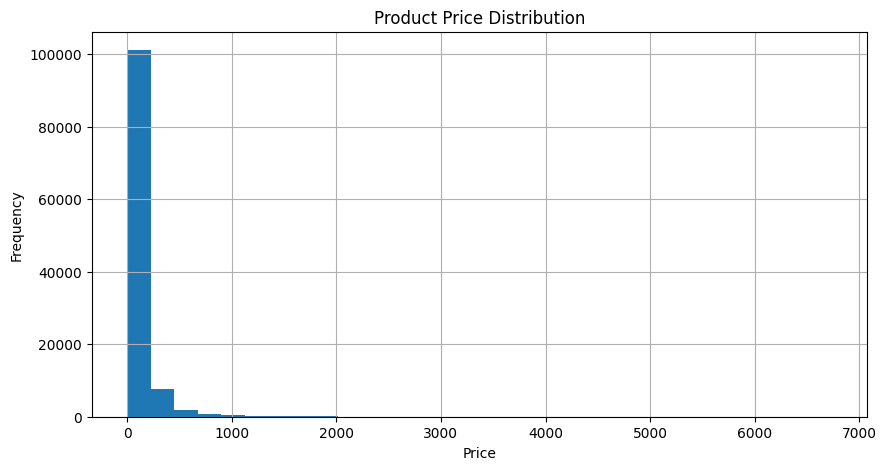

In [29]:
import matplotlib.pyplot as plt

items['price'].hist(bins=30, figsize=(10,5))

plt.title('Product Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**5 Business Insights**
1. Highest revenue category contributes significantly to overall sales.
2. Lowest-performing categories generate minimal revenue and may need marketing support.
3. Revenue peaks during certain months, indicating seasonal demand.
4. A few states contribute a major portion of revenue.
5. Most orders are successfully delivered, indicating strong operational performance.

In [30]:
products = pd.read_csv("olist_products_dataset.csv")

products.head()


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [31]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [32]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


The products dataset contained a small number of missing values. Around 610 products had missing category and description information, while only 2 records had missing physical dimensions. Since the percentage of missing values was very low, these records were removed during data cleaning to improve data quality

In [33]:
products = products.dropna(
    subset=['product_category_name']
)

products.shape

(32341, 9)

In [34]:
products.isnull().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,1
product_length_cm,1
product_height_cm,1
product_width_cm,1


In [35]:
translation = pd.read_csv("product_category_name_translation.csv")
translation.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [36]:
products = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [37]:
sales = items.merge(
    products,
    on='product_id',
    how='left'
)

sales.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [38]:
category_sales = sales.groupby(
    'product_category_name'
)['price'].sum().sort_values(
    ascending=False
)

category_sales.head(10)

,price
product_category_name,
beleza_saude,1258681.34
relogios_presentes,1205005.68
cama_mesa_banho,1036988.68
esporte_lazer,988048.97
informatica_acessorios,911954.32
moveis_decoracao,729762.49
cool_stuff,635290.85
utilidades_domesticas,632248.66
automotivo,592720.11


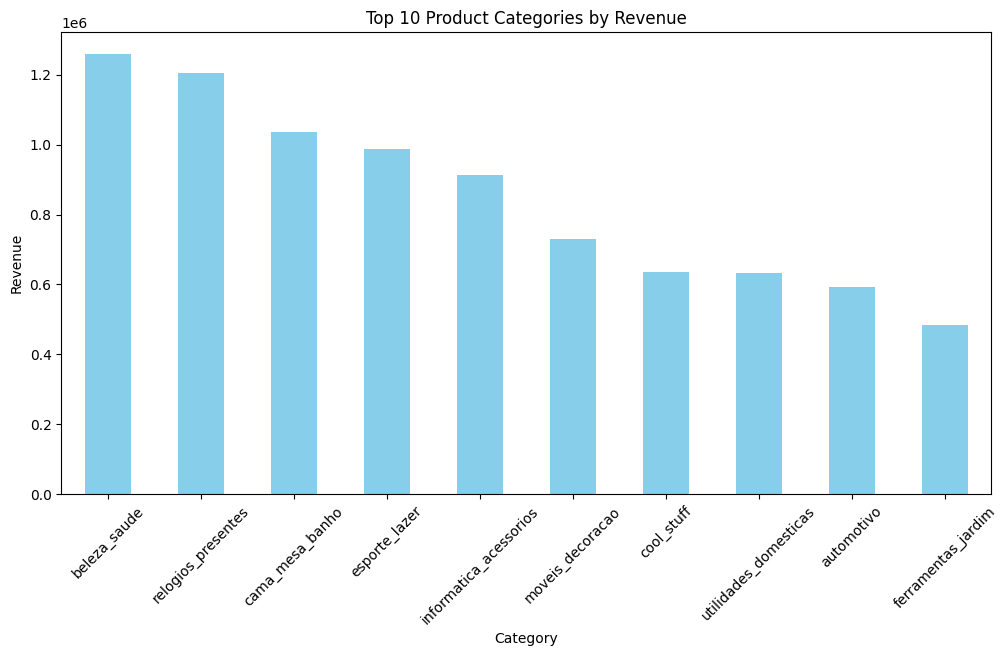

In [39]:
import matplotlib.pyplot as plt

category_sales.head(10).plot(
    kind='bar',
    color='skyblue',
    figsize=(12,6)
)

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

In [40]:
category_sales.tail(10)

,price
product_category_name,
fashion_esporte,2119.51
la_cuisine,2054.99
artes_e_artesanato,1814.01
fraldas_higiene,1567.59
pc_gamer,1545.95
flores,1110.04
casa_conforto_2,760.27
cds_dvds_musicais,730.00
fashion_roupa_infanto_juvenil,569.85


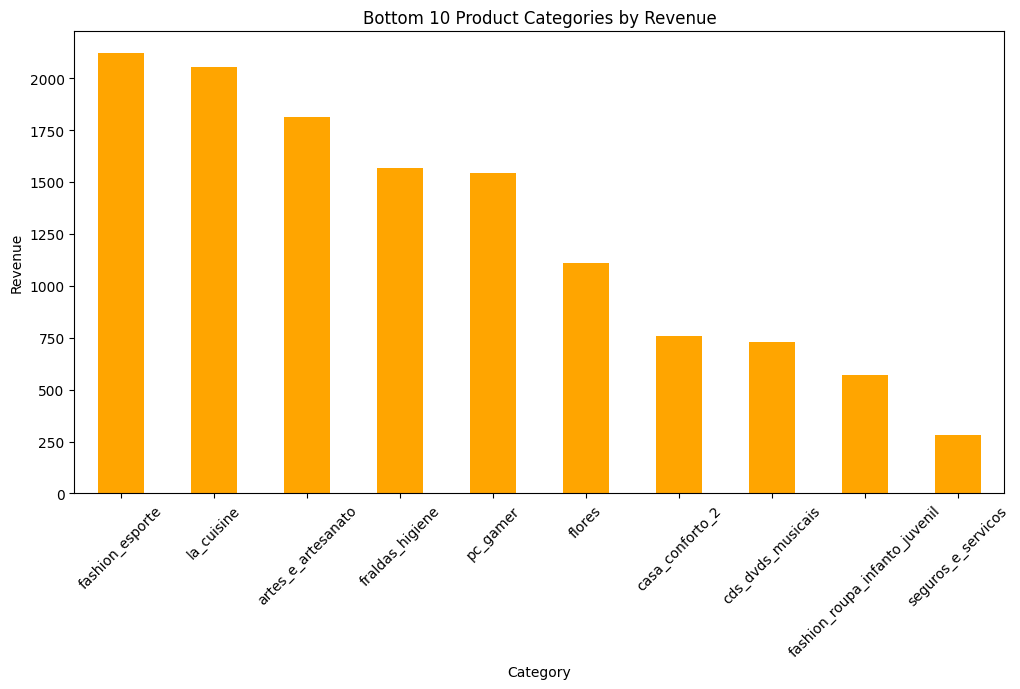

In [41]:
plt.figure(figsize=(12,6))

category_sales.tail(10).plot(
    kind='bar',
    color='orange'
)

plt.title('Bottom 10 Product Categories by Revenue')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

**Monthly Revenue Trend**

In [42]:
sales_orders = sales.merge(
    orders,
    on='order_id',
    how='left'
)

sales_orders['order_purchase_timestamp'] = pd.to_datetime(
    sales_orders['order_purchase_timestamp']
)

sales_orders['month_year'] = sales_orders[
    'order_purchase_timestamp'
].dt.to_period('M')

monthly_sales = sales_orders.groupby(
    'month_year'
)['price'].sum()

monthly_sales
#"Are there seasonal patterns in sales?"

,price
month_year,
2016-09,267.36
2016-10,49507.66
2016-12,10.90
2017-01,120312.87
2017-02,247303.02
2017-03,374344.30
2017-04,359927.23
2017-05,506071.14
2017-06,433038.60


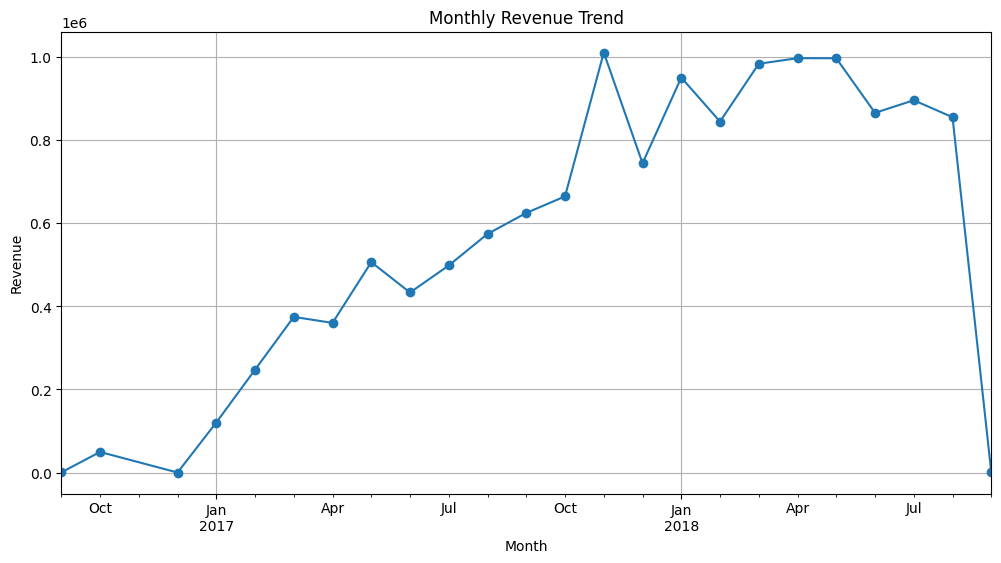

In [43]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    figsize=(12,6),
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)

plt.show()

In [44]:
"""Seasonal trend analysis revealed a strong increase in revenue over time.
 Sales peaked in November 2017 with revenue exceeding 1 million, followed by
 consistently high performance throughout early 2018. This suggests the
 presence of seasonal demand patterns, possibly driven by holiday shopping
 periods and promotional events. The business experienced significant growth
 between 2016 and 2018, indicating successful market expansion and increasing
 customer engagement.
 """

'Seasonal trend analysis revealed a strong increase in revenue over time.\n Sales peaked in November 2017 with revenue exceeding 1 million, followed by\n consistently high performance throughout early 2018. This suggests the\n presence of seasonal demand patterns, possibly driven by holiday shopping\n periods and promotional events. The business experienced significant growth\n between 2016 and 2018, indicating successful market expansion and increasing\n customer engagement.\n '

In [45]:
#"Which regions are underperforming?"

final_df = sales_orders.merge(
    df,
    on='customer_id',
    how='left'
)

state_sales = final_df.groupby(
    'customer_state'
)['price'].sum().sort_values(
    ascending=False
)

state_sales

,price
customer_state,
SP,5202955.05
RJ,1824092.67
MG,1585308.03
RS,750304.02
PR,683083.76
SC,520553.34
BA,511349.99
DF,302603.94
GO,294591.95


In [46]:
state_sales.head(10)

,price
customer_state,
SP,5202955.05
RJ,1824092.67
MG,1585308.03
RS,750304.02
PR,683083.76
SC,520553.34
BA,511349.99
DF,302603.94
GO,294591.95


In [47]:
state_sales.tail(10)

,price
customer_state,
PI,86914.08
RN,83034.98
AL,80314.81
SE,58920.85
TO,49621.74
RO,46140.64
AM,22356.84
AC,15982.95
AP,13474.30


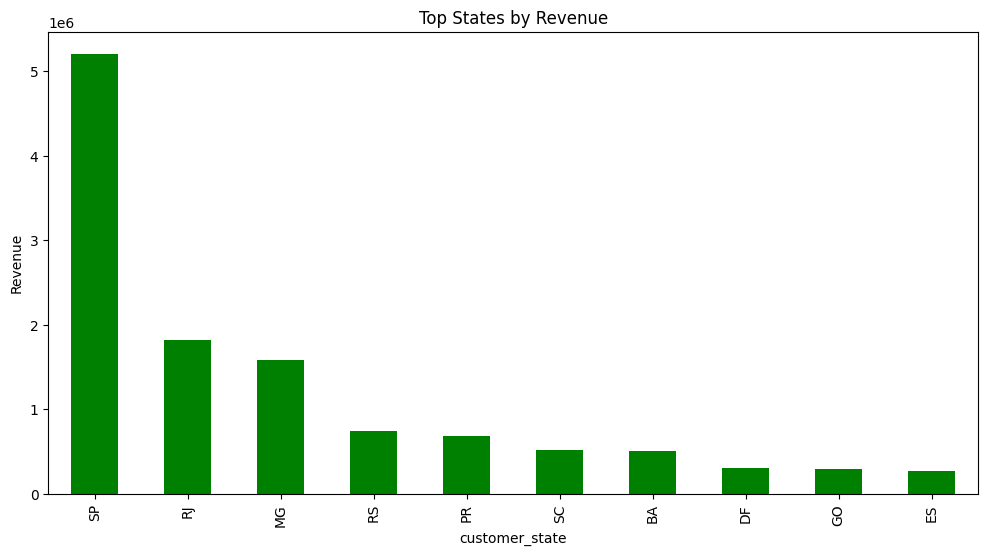

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

state_sales.head(10).plot(
    kind='bar',
    color='green'
)

plt.title('Top States by Revenue')
plt.ylabel('Revenue')
plt.show()

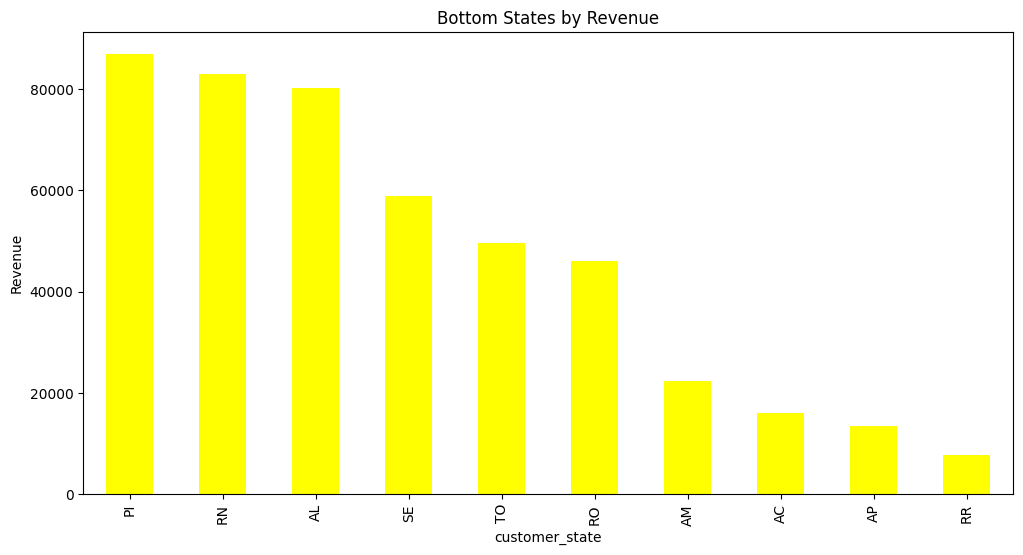

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

state_sales.tail(10).plot(
    kind='bar',
    color='yellow'
)

plt.title('Bottom States by Revenue')
plt.ylabel('Revenue')
plt.show()

**Final 5 Business Insights**

1. Health & Beauty emerged as the highest revenue-generating product category, indicating strong customer demand.

2. Revenue is concentrated among a few major categories, while several categories contribute very little to overall sales.

3. Sales revenue showed significant growth from 2016 to 2018, reflecting business expansion and increasing customer engagement.

4. November 2017 recorded the highest monthly revenue, suggesting strong seasonal demand during promotional and holiday periods.

5. São Paulo is the company's strongest market, contributing more revenue than any other state and serving as the primary driver of overall sales performance.




**Recommendation Section**

Recommendations

1. Increase marketing efforts in underperforming states such as RR, AP, AC, and AM to improve brand visibility and customer acquisition.

2. Focus inventory planning and promotional campaigns on high-performing categories such as Health & Beauty, Watches & Gifts, and Bed Bath Table products.

3. Leverage seasonal demand patterns by increasing stock availability before peak sales periods, especially during November and early-year months.

4. Strengthen customer engagement strategies in low-revenue regions through localized promotions and targeted advertising.

5. Continue investing in high-performing markets such as São Paulo, Rio de Janeiro, and Minas Gerais while exploring opportunities to expand in emerging regions.


In [51]:
from google.colab import files
files.download('Ecommerce_Sales_Analysis_Project1.ipynb')

FileNotFoundError: Cannot find file: Ecommerce_Sales_Analysis_Project1